## Home assignment 2. Sergeev Semion. Probability theory (visualisation of De Morgan's laws)

#### Criteria 1: description of your routine personal or professional tasks.
As a visual person who has not studied mathematics before I often visualise new concepts during my studies. It seems to me that such visualisations help me understand maths better. One of the recent examples include the De Morgan's laws.

#### Criteria 2: description of how Python can help automate routine tasks. 
De Morgan's laws may be easily seen on Venn-Euler diagrams. Instead of picturing it by hand it might be useful to automate the process so it becomes more universal and easily accessible to everyone. 

As such we may generate lists of integers which can later be transformed into sets. One large set may include two subsets of integers that share the elements that make them intersect with each other. 

The purpose of this effort would be to picture the proof of De Morgan's laws by inputing elements that are members of such sets or members of complements of such sets. For example, if the inputed integer does not belong to the union of subsets the program will check whether it belongs to subsets and complements of subsets giving a response "De Morgan's Law 1." It might further return a formula and visualisation on Venn-Euler diagram.

#### Criteria 3: python code

In [ ]:
import numpy as np
from matplotlib_venn import venn2, venn2_circles
from matplotlib import pyplot as plt
from matplotlib_venn import venn3, venn3_circles

event_a = set(list(range(7,21,1)))
print(event_a)

event_b = set(list(range(1,11,1)))
print(event_b)

sample_space = set(list(range(1,50,1)))

#sets for De Morgan Law 1
complement_union = sample_space - (event_a|event_b)
complement_event_a = sample_space - event_a
complement_event_b = sample_space - event_b
intersection_complements = complement_event_a & complement_event_b
union_events_a_b = event_a | event_b

if intersection_complements == complement_union:
    print("De Morgan's law 1")

#sets for De Morgan Law 2
intersection_events = event_a & event_b
complement_of_intersection = sample_space - intersection_events
union_complements = complement_event_a | complement_event_b

if complement_of_intersection == union_complements:
    print("De Morgan's law 2")
else:
    print("None")

{7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20}
{1, 2, 3, 4, 5, 6, 7, 8, 9, 10}
De Morgan's law 1
De Morgan's law 2


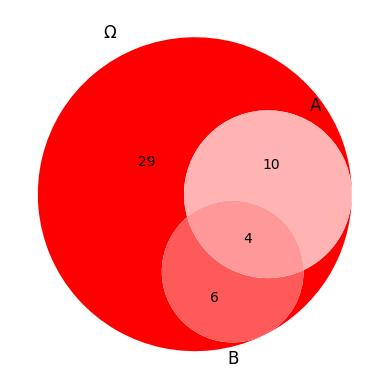

In [29]:
venn3([sample_space, event_a, event_b], ('Ω', 'A','B'), ('red','white','grey'), alpha = 1)

plt.show()

So far our code does not include an input function. So we can not test whether our hypothetical inputs are within the sets or their complements or not. Lets consider creating such statement and generating outputs.


In [32]:
element_a = int(input())

if element_a in complement_union:
    print("element a belongs to complement of the union")
else:
    print("element a belongs to the union of events")

element a belongs to complement of the union


Right now we have this but we would still need our program to check whether the element a is in complements of events. We also need our program to print the final output "De Morgan's law 1" if all conditions are satisfied.

In [31]:
element_a = int(input())

if element_a in complement_union:
    for i in iter(sample_space):
        if element_a in complement_event_a & complement_event_b: #looks whether it is in the complement of intersections
            print("element a is in complement of union and intersection of complements")
            break
    print("De Morgan's law 1")
else:
    for i in iter(sample_space):
        if element_a in union_events_a_b: #looks whether it is in the union of events
            print("element a is in event a union event b")
            break

element a is in complement of union and intersection of complements
De Morgan's law 1


Great! Now we can input the integer value ourselves for the program to check whether it is in the complement of intersection and union of complements of events a and b. Lets do the same for the proof of De Morgan's law 2. 

In [30]:
element_a = int(input())

if element_a in complement_of_intersection: #if else with for loop from the lecture notes
    for i in iter(sample_space): #found here https://www.geeksforgeeks.org/python/iterate-over-a-set-in-python/ 
        if element_a in complement_event_a | complement_event_b:
            print("element a is in complement of intersection and union of complements")
            break
    print("De Morgan's law 2")
else:
    for i in iter(sample_space):
        if element_a in intersection_events:
            print("element a is in intersection of events a and b")
            break

element a is in complement of intersection and union of complements
De Morgan's law 2


Great! Now we have the code, but there is still a need for visualisation of it. Furthermore we need a formula for us not to forget the De Morgan's laws 1 and 2.

De Morgan's law 1.
Element a is in complement of union or intersection of complements of events. Hence it is in red area.


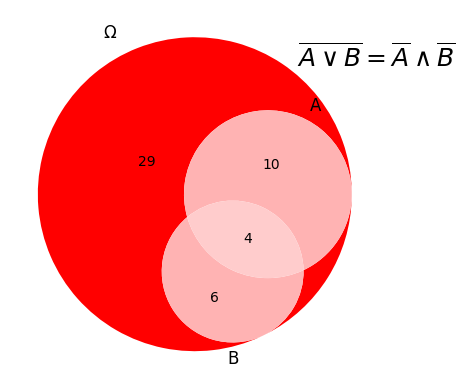

In [33]:
import matplotlib.pyplot as plt

element_a = int(input())

if element_a in complement_union:
    print("De Morgan's law 1.")
    for i in iter(sample_space):
        if element_a in complement_event_a & complement_event_b: #looks whether it is in the complement of intersections
            print("Element a is in complement of union or intersection of complements of events. Hence it is in red area.")
            break
    diagram = venn3([sample_space, event_a, event_b], ('Ω', 'A','B'), ('red','white','white'), alpha = 1)
    law_1 = r'$ \overline{A \vee B} = \overline{A} \wedge \overline{B}$' #found here https://matplotlib.org/stable/users/explain/text/text_intro.html 
    plt.text(0.3, 0.5, law_1, fontsize = 18)
    plt.savefig('De_Morgan_law_1.pdf') #found the function here https://stackoverflow.com/questions/9622163/save-plot-to-image-file-instead-of-displaying-it 
    plt.show()
    
else:
    for i in iter(sample_space):
        if element_a in union_events_a_b: #looks whether it is in the union of events
            print("element a is in event a union event b")
            break

De Morgan's law 2.
Element a is in complement of intersection or union of complements. Hence it is in red area.


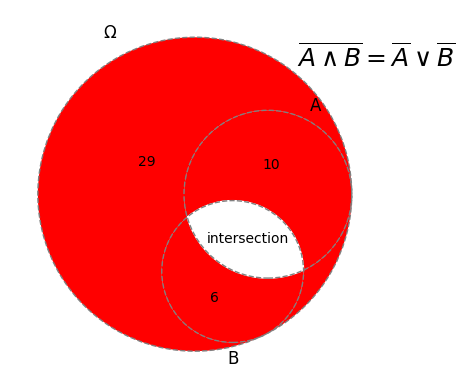

In [34]:
element_a = int(input())

if element_a in complement_of_interesection:
    print("De Morgan's law 2.")
    for i in iter(sample_space):
        if element_a in complement_event_a | complement_event_b:
            print("Element a is in complement of intersection or union of complements. Hence it is in red area.")
            break
    diagram = venn3([sample_space, event_a, event_b], ('Ω', 'A', 'B'), ('red','red','red'), alpha = 1)
    venn3_circles([sample_space, event_a, event_b], linestyle = 'dashed', linewidth = 1, color = "grey") #used from this webpage https://python-graph-gallery.com/172-custom-venn-diagram/ 
    diagram.get_patch_by_id('111').set_color('white')
    diagram.get_label_by_id('111').set_text('intersection') # found in these 3 sources https://stackoverflow.com/questions/77704406/how-to-isolate-parts-of-a-venn-diagram ; https://stackoverflow.com/questions/19841535/python-matplotlib-venn-diagram ; https://pypi.org/project/matplotlib-venn/ 
    law_2 = r'$ \overline{A \wedge B} = \overline{A} \vee \overline{B}$'
    plt.text(0.3, 0.5, law_2, fontsize = 18)
    plt.savefig('De_Morgan_law_2.pdf') #found the function here https://stackoverflow.com/questions/9622163/save-plot-to-image-file-instead-of-displaying-it 
    plt.show()
    
else:
    for i in iter(sample_space):
        if element_a in intersection_events:
            print("element a is in intersection of events a and b")
            break

#### Criteria 4: use of test data and Criteria 5: optimise and augment the code

Above graphs look fine, but it is possible to expand the use of De Morgan's laws to the data sets.

For this I will generate a dataset with the help of LLM that will contain three columns. I am organising tea parties, and I want to find out whether I have got same kinds of pastries and baverages in my last two parties for which I have created a list. 

We may use the same approach as above, for example, to find out which set of groceries is excluded from both lists and any other groceries that are in the local convinence store. 

I have successfully generated a data set with the following prompts: 

prompt 1: "give three columns data set in csv format for me to analyse with pandas. one column containing 10 obseration with various drinks(kinds of tea and coffee) and pastries from the party_1. another column, party_2 that contain 13 observations that has 4 elements same as in the party_1 column and all the rest are different from the party_1 column (those should be also different kinds of tea and pastries). and the third column that has all that elements from the column 1 and column 2 as well as other elements that are not included."

prompt 2: "first column of length 10 should include unique values. second column of length 13 should share 5 values with the first column. third column should include all values from first and second columns as well as other values."

In [ ]:
os.chdir("D:\py_programming\data")

data = pd.read_csv('./tea_party.csv')

tea_party = data['party_1,party_2,master_list'].str.split(',', expand = True) # seen for transformation here https://medium.com/@heyamit10/master-pandas-split-column-by-delimiter-f66d0a602e4d 

tea_party

<>:7: SyntaxWarning: invalid escape sequence '\p'
<>:7: SyntaxWarning: invalid escape sequence '\p'
C:\Users\SEMEN\AppData\Local\Temp\ipykernel_18084\3189816657.py:7: SyntaxWarning: invalid escape sequence '\p'
  os.chdir("D:\py_programming\data")


,0,1,2
0,Earl Grey Tea,Earl Grey Tea,Earl Grey Tea
1,Green Tea,Green Tea,Green Tea
2,Ceylon Tea,Ceylon Tea,Ceylon Tea
3,Espresso,Espresso,Espresso
4,Cappuccino,Cappuccino,Cappuccino
5,Blueberry Muffin,Matcha Latte,Blueberry Muffin
6,Butter Croissant,Latte Macchiato,Butter Croissant
7,Cheese Danish,Iced Hibiscus Tea,Cheese Danish
8,Apple Turnover,Lemon Ginger Tea,Apple Turnover
9,Pain au Chocolat,Almond Biscotti,Pain au Chocolat


In [36]:
party_1 = set(tea_party[0])
party_2 = set(tea_party[1])
combini = set(tea_party[2])

In [ ]:
complement_union_parties = combini - (party_1|party_2)
complement_party_1 = combini - party_1
complement_party_2 = combini - party_2
intersection_complements_party = complement_party_1 & complement_party_2
union_parties_1_2 = party_1 | party_2


intersection_parties = party_1 & party_2
complement_of_intersection_parties = combini - intersection_parties
union_complements_parties = complement_party_1 | complement_party_2

only_combini = combini - party_1 - party_2

We have transformed our lists into sets. So we are ready to make use of our functions which we have defined in De Morgan's Laws.

Treat has not been in either of the parties
Treat has not been in both of the parties.
Treat is only in combini. Go to combini for the following basket of groceries
{'English Breakfast Tea', 'Scone', 'Bear Claw', 'Oolong Tea', 'Fruit Tart'}


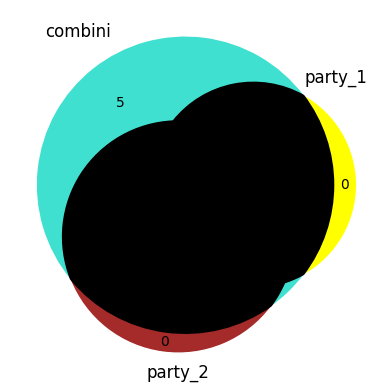

In [40]:
treat = input()

if treat in complement_union_parties:
    print("Treat has not been in either of the parties")
    for i in iter(combini):
        if treat in complement_party_1 & complement_party_2: #looks whether it is in the complement of intersections
            print('Treat has not been in both of the parties.')
            break
    diagram = venn3([combini, party_1, party_2], ('combini', 'party_1','party_2'), ('turquoise','yellow','brown'), alpha = 1)
    diagram.get_patch_by_id('111').set_color('black')
    diagram.get_patch_by_id('110').set_color('black')
    diagram.get_patch_by_id('101').set_color('black')
    print('Treat is only in combini. Go to combini for the following basket of groceries')
    print(only_combini)
    plt.show()
else:
    for i in iter(combini):
        if treat in union_parties_1_2: #looks whether it is in the union of events
            print("Treat is at home")
            break

Both parties did not have this treat for 100 percent.
So this treat is relatively new or completely new.


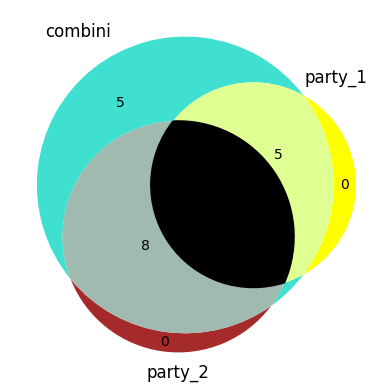

: 

: 

In [ ]:
not_verified_treat = input()

if not_verified_treat in complement_of_intersection_parties:
    for i in iter(combini):
        if not_verified_treat in complement_party_1 | complement_party_2:
            print('Both parties did not have this treat for 100 percent.')
            break
    diagram = venn3([combini, party_1, party_2], ('combini', 'party_1','party_2'), ('turquoise','yellow','brown'), alpha = 1)
    diagram.get_patch_by_id('111').set_color('black')
    print('So this treat is relatively new or completely new.')
    plt.show()   
else:
    for i in iter(combini):
        if not_verified_treat in intersection_parties:
            print("Everyone liked this treat very much. So I will make it a convention")
            break

#### Criteria 6: description of the solution

So this technical solution seems to be interesting. However, it does not seem to be as much versatile as I would want it to be. I would be more interested to see for the proof of De Morgan's Laws using any of the tools. 

I would definitely want to try visualisations of multiple mathematical concepts. I think when you programm you get better understanding of it. Moreover other people may use it as well. So, for example, I had seen a nice visualisation of formation of normal distribution connected to falling objects that are filtered by Pascal's triangle. I would definitely want to try that kind of a thing. 

08.04.2026

Semion Sergeev
